# Fake Image Detection with ELA and CNN

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
%matplotlib inline

np.random.seed(2)

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import itertools

from tensorflow.keras.utils import to_categorical # convert to one-hot-encoding
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
from keras.optimizers import RMSprop
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import ReduceLROnPlateau, EarlyStopping

sns.set(style='white', context='notebook', palette='deep')

## Initial preparation

In [2]:
from PIL import Image
import os
from pylab import *
import re
from PIL import Image, ImageChops, ImageEnhance

#### Functions

In [3]:
def get_imlist(path):
    return [os.path.join(path,f) for f in os.listdir(path) if f.endswith('.jpg') or f.endswith('.png')]

In [4]:
def convert_to_ela_image(path, quality):
    filename = path
    resaved_filename = filename.split('.')[0] + '.resaved.jpg'
    ELA_filename = filename.split('.')[0] + '.ela.png'

    im = Image.open(filename).convert('RGB')
    im.save(resaved_filename, 'JPEG', quality=quality)
    resaved_im = Image.open(resaved_filename)

    ela_im = ImageChops.difference(im, resaved_im)

    extrema = ela_im.getextrema()
    max_diff = max([ex[1] for ex in extrema])
    if max_diff == 0:
        max_diff = 1
    scale = 255.0 / max_diff

    ela_im = ImageEnhance.Brightness(ela_im).enhance(scale)

    return ela_im

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import os
base = "/content/drive/MyDrive/DATASET BARU"
for item in os.listdir(base):
    sub = os.path.join(base, item)
    if os.path.isdir(sub):
        files = os.listdir(sub)
        print(f"{item}/ → {len(files)} files → contoh: {files[0]}")

models/ → 8 files → contoh: ela amplify 30 eoch 75 dan batchsize 75 93,26acc.h5
TRAIN/ → 2 files → contoh: ASLI
TEST/ → 2 files → contoh: ASLI


### Sample: Real Image

Let's open a real (not-fake) image as a sample.

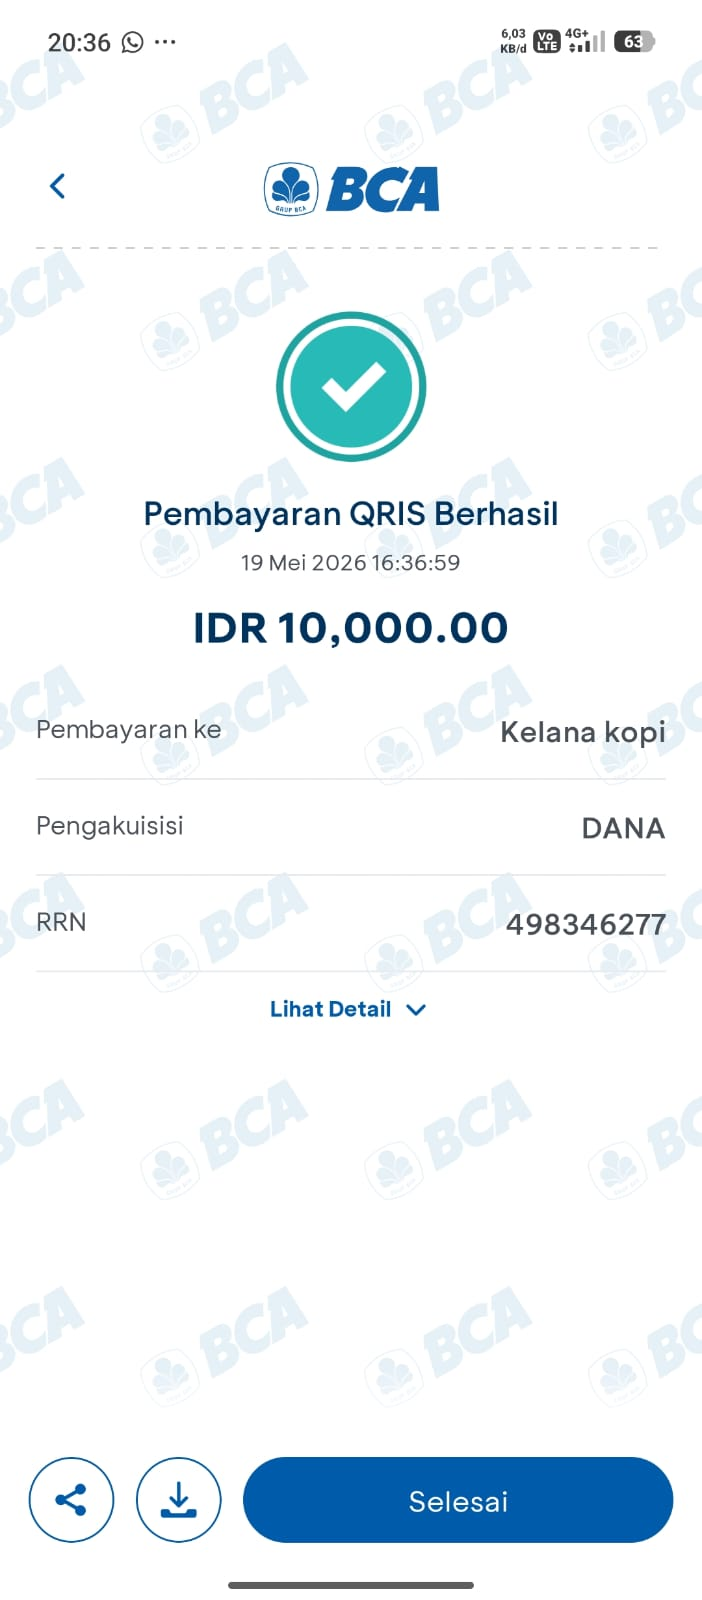

In [7]:
Image.open('/content/drive/MyDrive/DATASET BARU/TRAIN/ASLI/IMG-20260525-WA0110.jpg')

This is how it looks like after it is processed with error-level analysis (ELA).

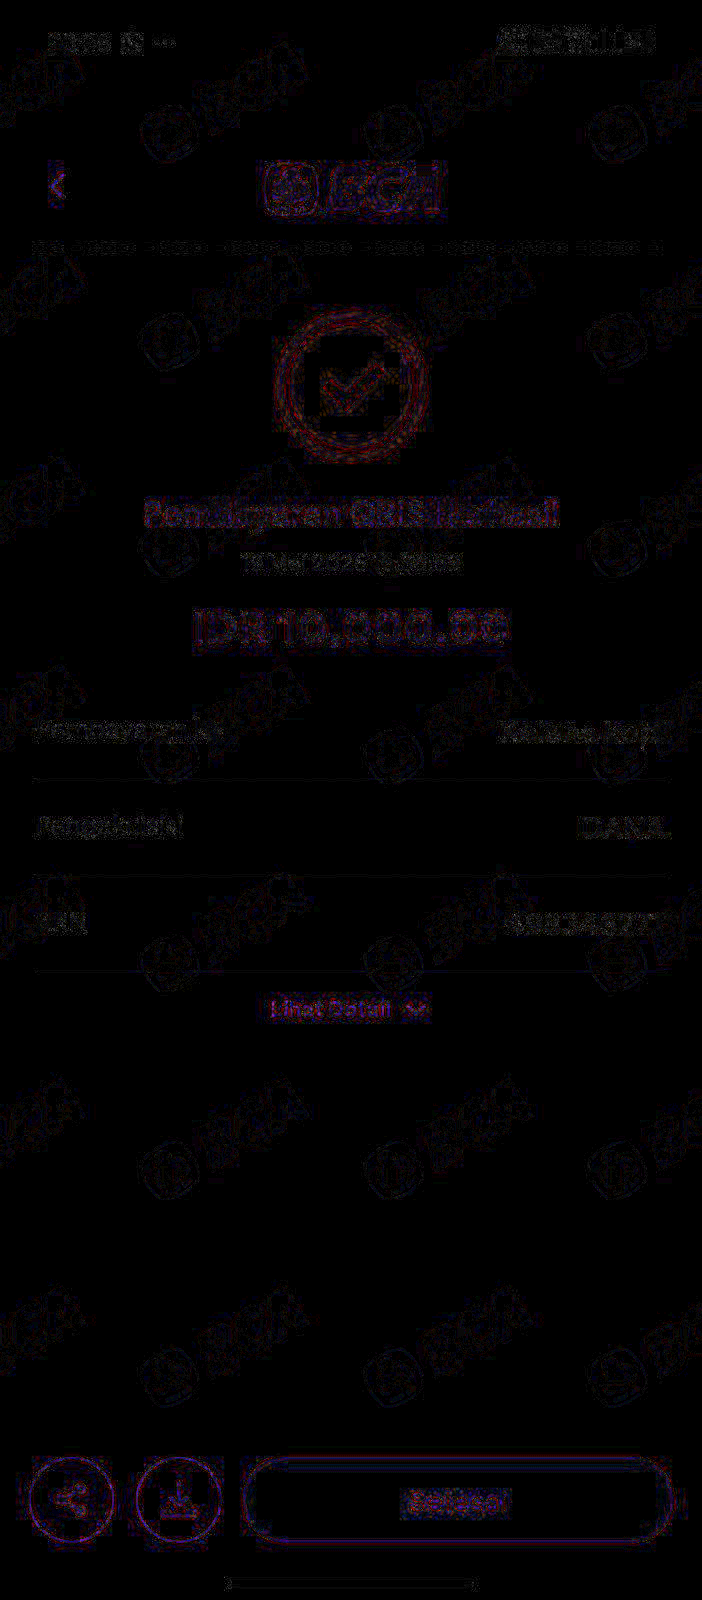

In [8]:
convert_to_ela_image('/content/drive/MyDrive/DATASET BARU/TRAIN/ASLI/IMG-20260525-WA0110.jpg', 90)

### Sample: Fake Image

This is how it looks like after it has been edited.

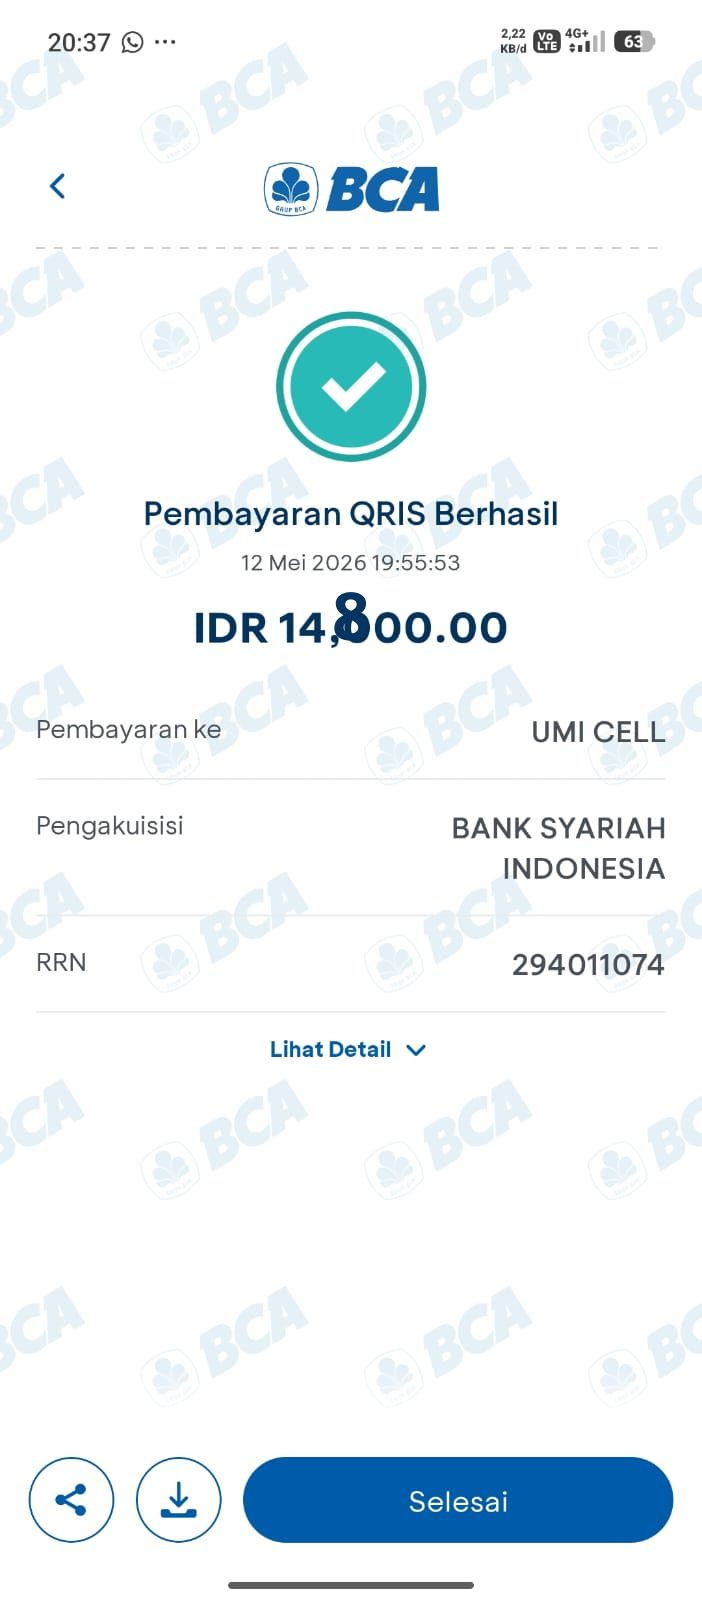

In [9]:
Image.open('/content/drive/MyDrive/DATASET BARU/TRAIN/PALSU/8 (3).jpg')

This is the result of the fake image after getting through ELA. We can compare the difference between the picture below and the real picture's ELA result.

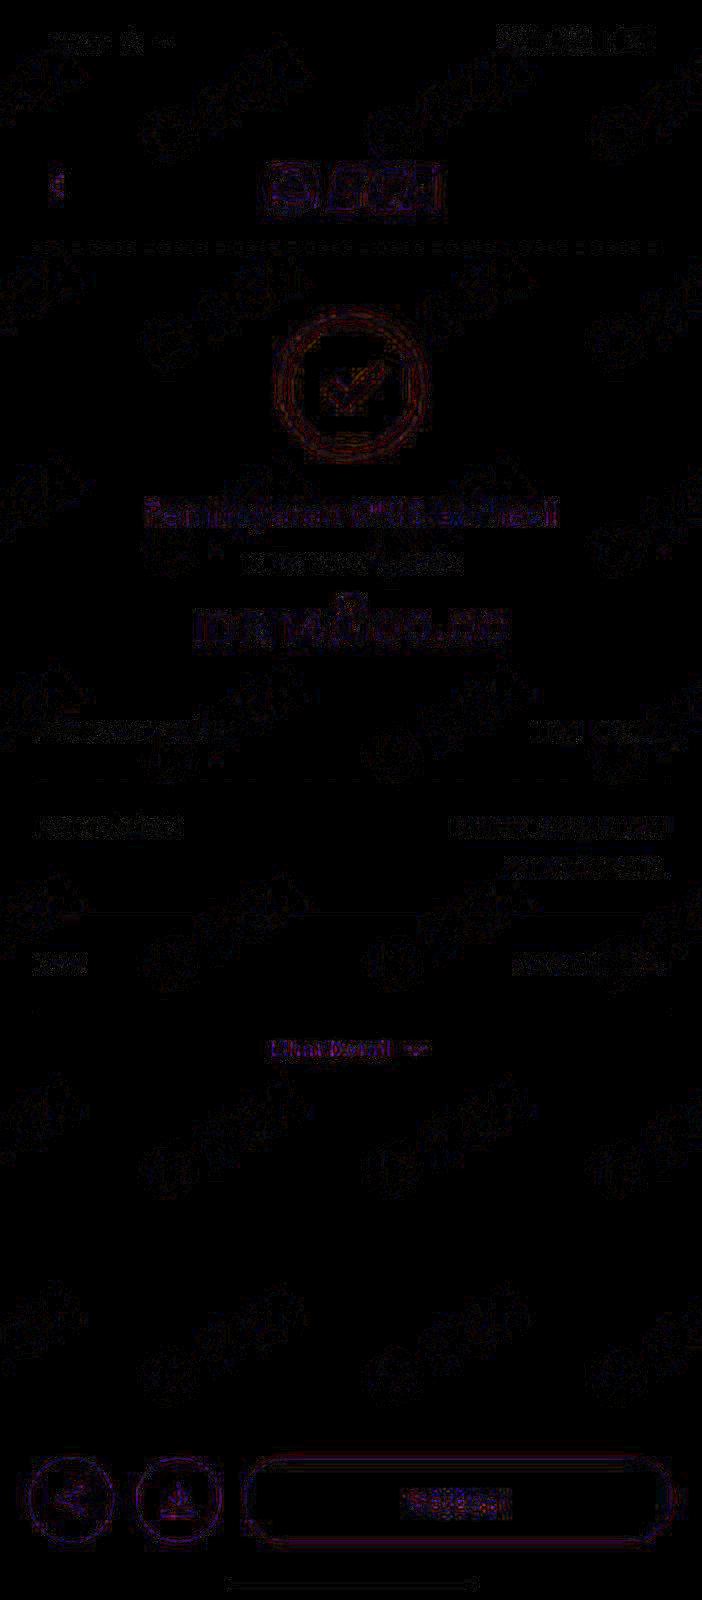

In [10]:
convert_to_ela_image('/content/drive/MyDrive/DATASET BARU/TRAIN/PALSU/8 (3).jpg', 90)

With our own naked eyes, we are able to differ which is the ELA result of the real picture and which one is the result of fake image. By saying real here, what we mean is a non-CGI picture that is not fabricated/edited in any way, e.g. splicing.

## Data preparation

### Read dataset and conversion to ELA

In [14]:
TRAIN_ASLI  = '/content/drive/MyDrive/DATASET BARU/TRAIN/ASLI'
TRAIN_PALSU = '/content/drive/MyDrive/DATASET BARU/TRAIN/PALSU'
TEST_ASLI   = '/content/drive/MyDrive/DATASET BARU/TEST/ASLI'
TEST_PALSU  = '/content/drive/MyDrive/DATASET BARU/TEST/PALSU'
ELA_QUALITY = 90
IMG_SIZE    = 128

X, Y = [], []

print("Loading ASLI...")
for path in get_imlist(TRAIN_ASLI):
    try:
        # FIX: Removed ELA_AMPLIFY from the call as convert_to_ela_image takes only 2 arguments
        ela = convert_to_ela_image(path, ELA_QUALITY)
        ela = ela.resize((IMG_SIZE, IMG_SIZE))
        X.append(np.array(ela, dtype=np.float32) / 255.0)
        Y.append(1)   # ASLI = 1
    except Exception as e:
        print(f"  Skip: {path} → {e}")

print("Loading PALSU...")
for path in get_imlist(TRAIN_PALSU):
    try:
        # FIX: Removed ELA_AMPLIFY from the call as convert_to_ela_image takes only 2 arguments
        ela = convert_to_ela_image(path, ELA_QUALITY)
        ela = ela.resize((IMG_SIZE, IMG_SIZE))
        X.append(np.array(ela, dtype=np.float32) / 255.0)
        Y.append(0)   # PALSU = 0
    except Exception as e:
        print(f"  Skip: {path} → {e}")

X = np.array(X)
# FIX: Changed 'keras.utils.to_categorical' to 'to_categorical' because it was imported directly
Y = to_categorical(Y, 2)   # one-hot: [1,0]=PALSU, [0,1]=ASLI

print(f"\nShape X : {X.shape}")
print(f"Shape Y : {Y.shape}")

Loading ASLI...
Loading PALSU...

Shape X : (885, 128, 128, 3)
Shape Y : (885, 2)


In [15]:
X = []
Y = []

In [18]:
import pandas as pd
from numpy import array

# Initialize X and Y as lists to allow appending, as they might be numpy arrays from previous cells.
X = []
Y = []

# Construct the dataset DataFrame from existing image directories
data = []
# ASLI_DIR and PALSU_DIR are defined in a previous cell (JTsy-ymgzwR3)
# get_imlist is defined in a previous cell (aTd8x-UlzwR0)
for path in get_imlist(TRAIN_ASLI):
    data.append([path, 1]) # 1 for ASLI
for path in get_imlist(TRAIN_PALSU):
    data.append([path, 0]) # 0 for PALSU

dataset = pd.DataFrame(data, columns=['image_path', 'label'])

# Original code from the user's selected cell, adapted to use defined constants
for index, row in dataset.iterrows():
    # convert_to_ela_image is defined in mC1rSBrszwR0
    # ELA_QUALITY (90) and IMG_SIZE (128) are defined in JTsy-ymgzwR3
    X.append(array(convert_to_ela_image(row['image_path'], ELA_QUALITY).resize((IMG_SIZE, IMG_SIZE))).flatten() / 255.0)
    Y.append(row['label'])

### Normalization

In [19]:
X = np.array(X)
Y = to_categorical(Y, 2)

### Reshape X

In [20]:
X = X.reshape(-1, 128, 128, 3)

## Train-test split

In [21]:
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size = 0.2, random_state=5)

Augmentation

In [22]:
import tensorflow.keras as keras
from tensorflow.keras import layers
import tensorflow as tf

# BLOK 5 — AUGMENTASI (geometric only, NO brightness)
# ─────────────────────────────────────────────────────────────────────
augmentation = keras.Sequential([
    # ── Spatial ──────────────────────────────────────────────────────
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15),          # ±15% ≈ ±54°
    layers.RandomZoom(0.15),              # zoom in/out 15%
    layers.RandomTranslation(0.10, 0.10), # geser horizontal & vertikal 10%

    # ── Distorsi ringan ───────────────────────────────────────────────
    layers.RandomShear(x_factor=0.10, y_factor=0.10),  # miring tipis

    # ── Warna — TANPA brightness ──────────────────────────────────────
    layers.RandomContrast(0.15),          # kontras ±15% (bukan brightness!)
    layers.RandomSaturation(0.10),        # saturasi tipis

], name="augmentation")

# Normalisasi sudah dilakukan saat ELA loading (/ 255.0)
# → TIDAK perlu Rescaling layer lagi

AUTOTUNE = tf.data.AUTOTUNE

def prepare_train(ds):
    return (
        ds
        .map(lambda x, y: (augmentation(x, training=True), y),
             num_parallel_calls=AUTOTUNE)
        .cache()
        .prefetch(AUTOTUNE)
    )

def prepare_val(ds):
    return ds.cache().prefetch(AUTOTUNE)

# Create TensorFlow datasets from NumPy arrays
train_ds = tf.data.Dataset.from_tensor_slices((X_train, Y_train))
val_ds = tf.data.Dataset.from_tensor_slices((X_val, Y_val))

train_ready = prepare_train(train_ds)
val_ready   = prepare_val(val_ds)


In [24]:
epochs = 101 # Define epochs as it's used in the next cell and defined later in the notebook.

In [25]:
# Jumlah data SEBELUM augmentasi (ini yang ADA angkanya)
print("Jumlah data train sebelum augmentasi:", len(X_train))
print("Jumlah data val sebelum augmentasi  :", len(X_val))

# Augmentasi kamu jalan ON-THE-FLY (di dalam train_ready), jadi
# TIDAK menambah jumlah baris di X_train. Jumlahnya tetap sama
# sebelum dan sesudah -- nggak ada angka "setelah augmentasi"
# untuk dicetak, karena memang nggak ada array baru yang dibuat.

# Yang BERUBAH itu cuma berapa KALI tiap gambar "dilihat" model
# selama training, bukan jumlah baris datanya:
print("\nTotal 'kemunculan' gambar selama training =")
print("epochs x len(X_train) =", epochs, "x", len(X_train), "=", epochs * len(X_train))

Jumlah data train sebelum augmentasi: 708
Jumlah data val sebelum augmentasi  : 177

Total 'kemunculan' gambar selama training =
epochs x len(X_train) = 101 x 708 = 71508


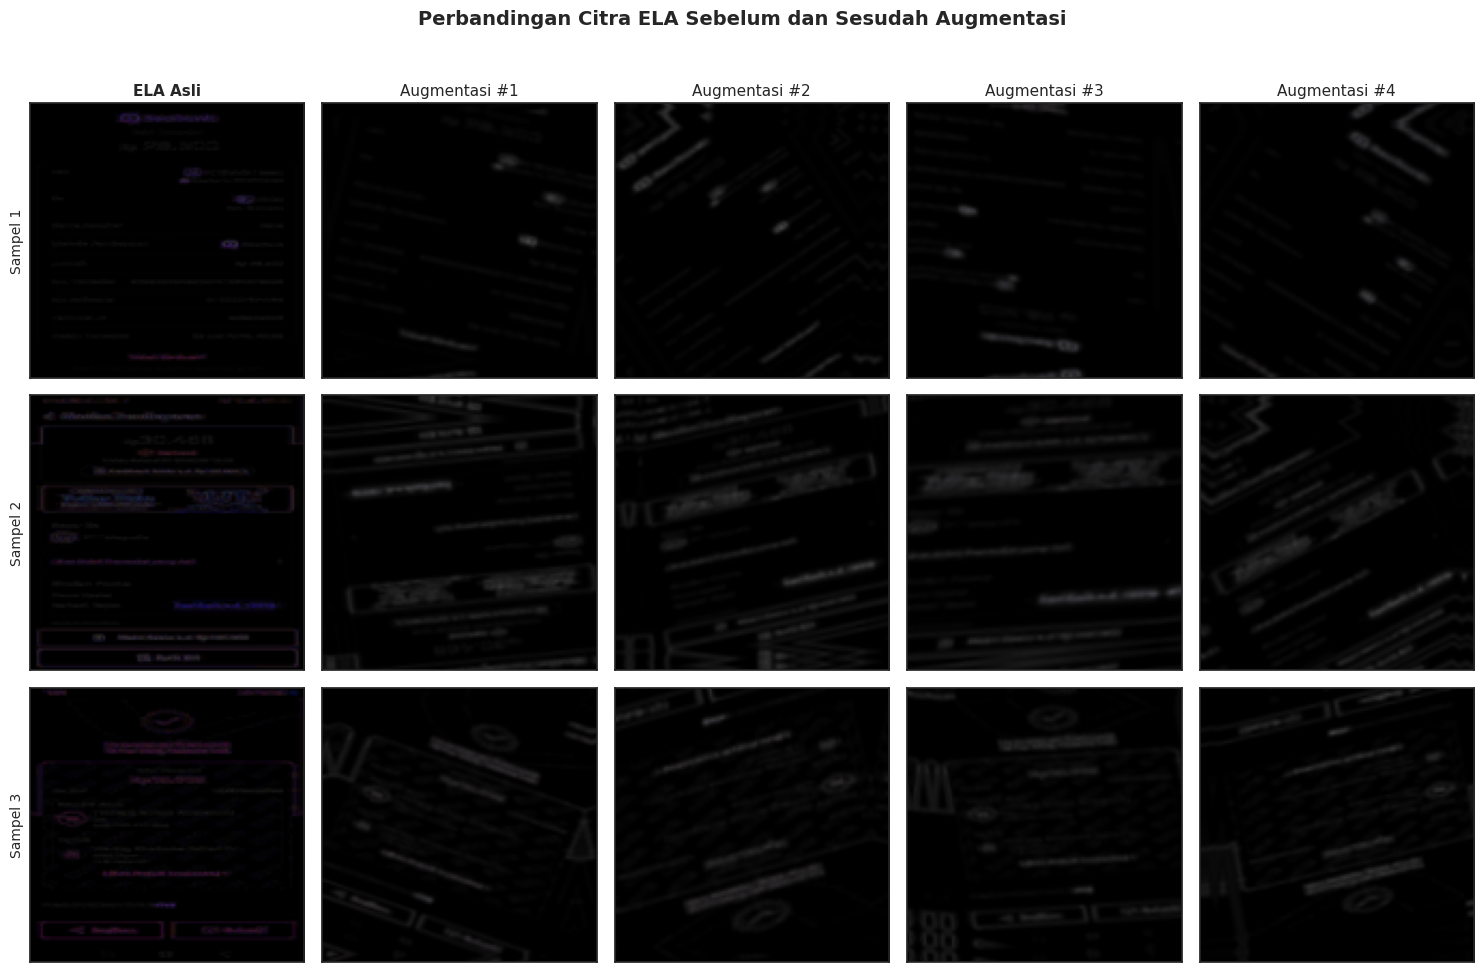


Gambar tersimpan ke Drive sebagai 'hasil_augmentasi.png'.
Bisa langsung dipakai sebagai Gambar di Bab 4.1.1 naskah, dengan
caption menjelaskan teknik yang dipakai: RandomFlip, RandomRotation
(±15%), RandomZoom (±15%), RandomTranslation (±10%), RandomShear
(±10%), RandomContrast (±15%), RandomSaturation (±10%) -- TANPA
perubahan brightness, supaya sinyal inkonsistensi kompresi ELA
tidak ikut terdistorsi.


In [26]:
# =========================================================
# VISUALISASI HASIL AUGMENTASI — taruh sebagai cell BARU
# setelah blok augmentasi (BLOK 5) yang sudah kamu punya.
# =========================================================
# Ini TIDAK training apa pun. Cuma ambil beberapa gambar dari
# X_train, jalankan augmentation() langsung (bukan lewat
# train_ready yang sudah di-cache), lalu plot perbandingan
# sebelum vs sesudah augmentasi.

import matplotlib.pyplot as plt
import numpy as np

# =========================================================
# KONFIGURASI
# =========================================================
JUMLAH_GAMBAR_CONTOH = 3      # berapa gambar asli yang mau ditunjukkan
JUMLAH_VARIASI_PER_GAMBAR = 4 # berapa hasil augmentasi per gambar


# =========================================================
# AMBIL BEBERAPA GAMBAR CONTOH DARI X_train
# =========================================================
indeks_contoh = np.random.choice(len(X_train), size=JUMLAH_GAMBAR_CONTOH, replace=False)

total_baris = JUMLAH_GAMBAR_CONTOH
total_kolom = JUMLAH_VARIASI_PER_GAMBAR + 1  # +1 untuk gambar asli

fig, axes = plt.subplots(total_baris, total_kolom,
                          figsize=(3 * total_kolom, 3.2 * total_baris))

# Kalau cuma 1 baris, axes perlu di-reshape supaya indexing tetap konsisten
if total_baris == 1:
    axes = axes.reshape(1, -1)

for row, idx in enumerate(indeks_contoh):
    gambar_asli = X_train[idx]
    # CATATAN: TIDAK pakai np.expand_dims di sini. Layer augmentation
    # di notebook kamu (Keras 3) sudah otomatis ter-build untuk
    # menerima shape (128, 128, 3) langsung, TANPA dimensi batch.
    # Kalau ditambah expand_dims jadi (1, 128, 128, 3), malah ditolak
    # dengan error "Invalid input shape".

    # Tampilkan gambar asli di kolom pertama
    axes[row, 0].imshow(np.clip(gambar_asli, 0, 1))
    axes[row, 0].set_title("ELA Asli" if row == 0 else "", fontsize=11, fontweight='bold')
    axes[row, 0].set_ylabel(f"Sampel {row+1}", fontsize=10)
    axes[row, 0].set_xticks([])
    axes[row, 0].set_yticks([])

    # Jalankan augmentation() langsung -- BUKAN lewat train_ready,
    # supaya hasilnya benar-benar baru tiap kali script ini dijalankan
    for col in range(1, total_kolom):
        hasil_augmentasi = augmentation(gambar_asli, training=True)
        gambar_hasil = hasil_augmentasi.numpy()

        axes[row, col].imshow(np.clip(gambar_hasil, 0, 1))
        axes[row, col].set_title(f"Augmentasi #{col}" if row == 0 else "", fontsize=11)
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])

plt.suptitle("Perbandingan Citra ELA Sebelum dan Sesudah Augmentasi",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

# Simpan ke Drive supaya bisa langsung dipakai untuk naskah
plt.savefig('/content/drive/MyDrive/DATASET BARU/hasil_augmentasi.png',
            dpi=200, bbox_inches='tight')
plt.show()

print("\nGambar tersimpan ke Drive sebagai 'hasil_augmentasi.png'.")
print("Bisa langsung dipakai sebagai Gambar di Bab 4.1.1 naskah, dengan")
print("caption menjelaskan teknik yang dipakai: RandomFlip, RandomRotation")
print("(±15%), RandomZoom (±15%), RandomTranslation (±10%), RandomShear")
print("(±10%), RandomContrast (±15%), RandomSaturation (±10%) -- TANPA")
print("perubahan brightness, supaya sinyal inkonsistensi kompresi ELA")
print("tidak ikut terdistorsi.")

## CNN building

In [27]:
model = Sequential()

model.add(Conv2D(filters = 32, kernel_size = (5,5),padding = 'valid',
                 activation ='relu', input_shape = (128,128,3)))
print("Input: ", model.input_shape)
print("Output: ", model.output_shape)

model.add(Conv2D(filters = 32, kernel_size = (5,5),padding = 'valid',
                 activation ='relu'))
print("Input: ", model.input_shape)
print("Output: ", model.output_shape)

model.add(MaxPool2D(pool_size=(2,2)))

model.add(Dropout(0.25))
print("Input: ", model.input_shape)
print("Output: ", model.output_shape)

model.add(Flatten())
model.add(Dense(256, activation = "relu"))
model.add(Dropout(0.5))
model.add(Dense(2, activation = "softmax"))

Input:  (None, 128, 128, 3)
Output:  (None, 124, 124, 32)
Input:  (None, 128, 128, 3)
Output:  (None, 120, 120, 32)
Input:  (None, 128, 128, 3)
Output:  (None, 60, 60, 32)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 124, 124, 32)   │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 120, 120, 32)   │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 60, 60, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 60, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    29,491,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,520,034 (112.61 MB)

 Trainable params: 29,520,034 (112.61 MB)

 Non-trainable params: 0 (0.00 B)

### Add optimizer

In [33]:
optimizer = RMSprop(learning_rate=0.0005, rho=0.9, epsilon=1e-08)

In [34]:
model.compile(optimizer = optimizer , loss = "categorical_crossentropy", metrics=["accuracy"])


### Define early stopping

In [35]:
early_stopping = EarlyStopping(monitor='val_acc',
                              min_delta=0,
                              patience=2,
                              verbose=0, mode='auto')

### Model training

In [50]:
epochs = 101
batch_size = 30

In [54]:
early_stopping = EarlyStopping(monitor='val_accuracy',
                              min_delta=0,
                              patience=2,
                              verbose=0, mode='max') # Fix: changed monitor to 'val_accuracy'
history = model.fit(X_train, Y_train, batch_size = batch_size, epochs = epochs,
          validation_data = (X_val, Y_val), verbose = 2, callbacks=[early_stopping])

Epoch 1/101
24/24 - 1s - 40ms/step - accuracy: 0.9859 - loss: 0.0309 - val_accuracy: 0.9209 - val_loss: 0.4386
Epoch 2/101
24/24 - 1s - 35ms/step - accuracy: 0.9915 - loss: 0.0287 - val_accuracy: 0.9266 - val_loss: 0.4494
Epoch 3/101
24/24 - 1s - 34ms/step - accuracy: 0.9887 - loss: 0.0344 - val_accuracy: 0.9266 - val_loss: 0.3947
Epoch 4/101
24/24 - 1s - 34ms/step - accuracy: 0.9929 - loss: 0.0271 - val_accuracy: 0.9096 - val_loss: 0.3929


## Performance measure

### Accuracy and loss curves during training-validation

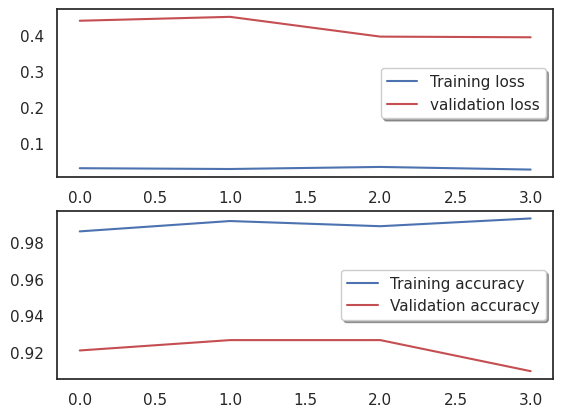

In [55]:
# Plot the loss and accuracy curves for training and validation
fig, ax = plt.subplots(2,1)
ax[0].plot(history.history['loss'], color='b', label="Training loss")
ax[0].plot(history.history['val_loss'], color='r', label="validation loss")
legend = ax[0].legend(loc='best', shadow=True)

ax[1].plot(history.history['accuracy'], color='b', label="Training accuracy")
ax[1].plot(history.history['val_accuracy'], color='r',label="Validation accuracy")
legend = ax[1].legend(loc='best', shadow=True)

### Confusion matrix

6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 261ms/step


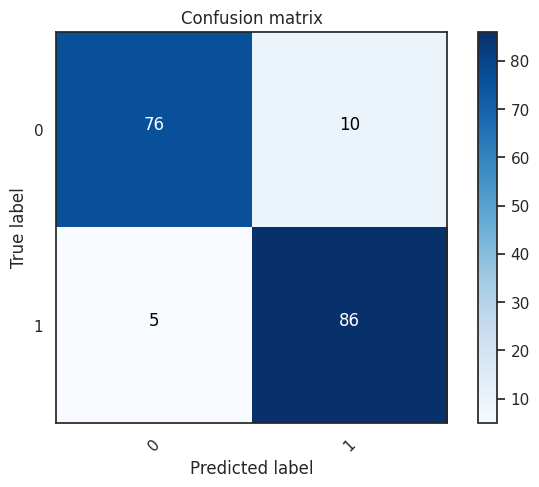

In [39]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')


# Predict the values from the validation dataset
Y_pred = model.predict(X_val)
# Convert predictions classes to one hot vectors
Y_pred_classes = np.argmax(Y_pred,axis = 1)
# Convert validation observations to one hot vectors
Y_true = np.argmax(Y_val,axis = 1)
# compute the confusion matrix
confusion_mtx = confusion_matrix(Y_true, Y_pred_classes)
# plot the confusion matrix
plot_confusion_matrix(confusion_mtx, classes = range(2))

In [40]:
from sklearn.metrics import classification_report, accuracy_score

print("="*45)
print("         EVALUATION SUMMARY")
print("="*45)

acc  = accuracy_score(Y_true, Y_pred_classes)
print(f"\n  Overall Accuracy : {acc*100:.2f}%")

print(f"\n  Confusion Matrix breakdown:")
print(f"  PALSU → benar: {confusion_mtx[0][0]} | salah prediksi ASLI : {confusion_mtx[0][1]}")
print(f"  ASLI  → benar: {confusion_mtx[1][1]} | salah prediksi PALSU: {confusion_mtx[1][0]}")

print("\n" + "="*45)
print(classification_report(Y_true, Y_pred_classes, target_names=['PALSU', 'ASLI']))

         EVALUATION SUMMARY

  Overall Accuracy : 91.53%

  Confusion Matrix breakdown:
  PALSU → benar: 76 | salah prediksi ASLI : 10
  ASLI  → benar: 86 | salah prediksi PALSU: 5

              precision    recall  f1-score   support

       PALSU       0.94      0.88      0.91        86
        ASLI       0.90      0.95      0.92        91

    accuracy                           0.92       177
   macro avg       0.92      0.91      0.91       177
weighted avg       0.92      0.92      0.92       177



In [42]:
model.save('/content/drive/MyDrive/DATASET BARU/models/fiks pake ini 101 epoch 30 batch size.h5')

In [43]:
# =========================================================
# CEK JUMLAH FILE DI MASING-MASING FOLDER DATASET
# =========================================================
# Script ini cuma MENGHITUNG, tidak menghapus atau mengubah apa pun.
# Dijalankan di Colab setelah drive.mount() seperti biasa.
#
# Menghitung dipisah jadi:
#   - gambar asli (.jpg/.png/.jpeg, BUKAN .resaved.jpg)
#   - file .resaved.jpg (sisa proses ELA, kalau masih ada)
#   - total semua file di folder itu (untuk sanity check)

import os

# =========================================================
# KONFIGURASI — sesuaikan kalau struktur foldermu beda
# =========================================================
FOLDERS_TO_CHECK = {
    'TRAIN/ASLI':  '/content/drive/MyDrive/DATASET BARU/TRAIN/ASLI',
    'TRAIN/PALSU': '/content/drive/MyDrive/DATASET BARU/TRAIN/PALSU',
    'TEST/ASLI':   '/content/drive/MyDrive/DATASET BARU/TEST/ASLI',
    'TEST/PALSU':  '/content/drive/MyDrive/DATASET BARU/TEST/PALSU',
}

IMG_EXTENSIONS = ('.jpg', '.jpeg', '.png')

# =========================================================
# HITUNG PER FOLDER
# =========================================================
print("=" * 60)
print(f"{'Folder':<15} {'Gambar Asli':<13} {'.resaved.jpg':<14} {'Total File'}")
print("=" * 60)

rekap = {}

for label, folder in FOLDERS_TO_CHECK.items():
    if not os.path.isdir(folder):
        print(f"{label:<15} [FOLDER TIDAK DITEMUKAN: {folder}]")
        continue

    semua_file = os.listdir(folder)

    jumlah_resaved = sum(1 for f in semua_file if f.lower().endswith('.resaved.jpg'))
    jumlah_gambar_asli = sum(
        1 for f in semua_file
        if f.lower().endswith(IMG_EXTENSIONS) and not f.lower().endswith('.resaved.jpg')
    )
    total = len(semua_file)

    rekap[label] = {
        'gambar_asli': jumlah_gambar_asli,
        'resaved': jumlah_resaved,
        'total': total
    }

    print(f"{label:<15} {jumlah_gambar_asli:<13} {jumlah_resaved:<14} {total}")

print("=" * 60)

# =========================================================
# RINGKASAN TRAIN VS TEST + RASIO
# =========================================================
total_train = rekap.get('TRAIN/ASLI', {}).get('gambar_asli', 0) + rekap.get('TRAIN/PALSU', {}).get('gambar_asli', 0)
total_test  = rekap.get('TEST/ASLI', {}).get('gambar_asli', 0) + rekap.get('TEST/PALSU', {}).get('gambar_asli', 0)
total_semua = total_train + total_test

print(f"\nTotal TRAIN : {total_train} gambar")
print(f"Total TEST  : {total_test} gambar")
print(f"Total semua : {total_semua} gambar")

if total_semua > 0:
    persen_train = total_train / total_semua * 100
    persen_test  = total_test / total_semua * 100
    print(f"\nRasio split : {persen_train:.1f}% train : {persen_test:.1f}% test")

# =========================================================
# CEK KESEIMBANGAN KELAS (ASLI vs PALSU)
# =========================================================
asli_train  = rekap.get('TRAIN/ASLI', {}).get('gambar_asli', 0)
palsu_train = rekap.get('TRAIN/PALSU', {}).get('gambar_asli', 0)
asli_test   = rekap.get('TEST/ASLI', {}).get('gambar_asli', 0)
palsu_test  = rekap.get('TEST/PALSU', {}).get('gambar_asli', 0)

print(f"\n--- Keseimbangan kelas TRAIN ---")
print(f"ASLI  : {asli_train}")
print(f"PALSU : {palsu_train}")

print(f"\n--- Keseimbangan kelas TEST ---")
print(f"ASLI  : {asli_test}")
print(f"PALSU : {palsu_test}")

# =========================================================
# PERINGATAN kalau masih ada file .resaved.jpg tersisa
# =========================================================
total_resaved = sum(v.get('resaved', 0) for v in rekap.values())
if total_resaved > 0:
    print(f"\n[INFO] Masih ada {total_resaved} file .resaved.jpg di folder dataset.")
    print("       Kalau mau dibersihkan, pakai script hapus_file_resaved.py.")

Folder          Gambar Asli   .resaved.jpg   Total File
TRAIN/ASLI      222           222            444
TRAIN/PALSU     222           219            441
TEST/ASLI       88            88             176
TEST/PALSU      88            88             176

Total TRAIN : 444 gambar
Total TEST  : 176 gambar
Total semua : 620 gambar

Rasio split : 71.6% train : 28.4% test

--- Keseimbangan kelas TRAIN ---
ASLI  : 222
PALSU : 222

--- Keseimbangan kelas TEST ---
ASLI  : 88
PALSU : 88

[INFO] Masih ada 617 file .resaved.jpg di folder dataset.
       Kalau mau dibersihkan, pakai script hapus_file_resaved.py.


/tmp/ipykernel_986/2642662892.py:42: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  jumlah_resaved = sum(1 for f in semua_file if f.lower().endswith('.resaved.jpg'))
/tmp/ipykernel_986/2642662892.py:43: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  jumlah_gambar_asli = sum(
/tmp/ipykernel_986/2642662892.py:94: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  total_resaved = sum(v.get('resaved', 0) for v in rekap.values())


In [44]:
# =========================================================
# CEK FILE MANA YANG GAGAL DIPROSES ELA DI TRAIN/PALSU
# =========================================================
# Script ini cuma MENCOBA proses ELA pada tiap file dan mencatat
# mana yang gagal -- TIDAK menghapus apa pun.
#
# Dijalankan SETELAH fungsi convert_to_ela_image() dan get_imlist()
# sudah didefinisikan di notebook kamu (cell yang sama seperti
# kode load TRAIN yang sebelumnya kamu kirim).

import os

PALSU_TRAIN_DIR = '/content/drive/MyDrive/DATASET BARU/TRAIN/PALSU'
ELA_QUALITY = 90
IMG_SIZE = 128

semua_file = get_imlist(PALSU_TRAIN_DIR)
print(f"Total file ditemukan di TRAIN/PALSU: {len(semua_file)}\n")

file_gagal = []
file_berhasil = []

for path in semua_file:
    try:
        ela = convert_to_ela_image(path, ELA_QUALITY)
        ela = ela.resize((IMG_SIZE, IMG_SIZE))
        file_berhasil.append(path)
    except Exception as e:
        file_gagal.append((path, str(e)))

print(f"Berhasil diproses : {len(file_berhasil)}")
print(f"Gagal diproses    : {len(file_gagal)}")

if file_gagal:
    print("\n--- Daftar file yang GAGAL diproses ---")
    for path, error in file_gagal:
        nama_file = os.path.basename(path)
        print(f"  {nama_file}  ->  {error}")
    print("\nFile-file di atas itu yang menyebabkan selisih jumlah .resaved.jpg")
    print("lebih sedikit dari jumlah file fisik. File ini TIDAK ikut dipakai")
    print("model saat training (otomatis di-skip oleh try/except).")
else:
    print("\nSemua file berhasil diproses tanpa error.")
    print("Berarti selisih 223 file fisik vs 220 .resaved.jpg kemarin")
    print("kemungkinan disebabkan hal lain (misal: ada file .resaved.jpg")
    print("lama yang sempat terhapus manual, bukan karena gagal proses).")

Total file ditemukan di TRAIN/PALSU: 441

Berhasil diproses : 441
Gagal diproses    : 0

Semua file berhasil diproses tanpa error.
Berarti selisih 223 file fisik vs 220 .resaved.jpg kemarin
kemungkinan disebabkan hal lain (misal: ada file .resaved.jpg
lama yang sempat terhapus manual, bukan karena gagal proses).
